# Comparing Chances to Social Media Guidelines Archived by the Platform Governance Archive

Preparations:

1. run the script [unroll-pga-versions.sh](./unroll-pga-versions.sh) which extracts the
   history of all versions and places them in `tmp-pga-versions-history/`


In [1]:
R.version.string

[1] "R version 4.3.3 (2024-02-29)"

In [2]:
library(commonmark)
library(digest)
library(dplyr)
library(readtext)
library(tidyverse)

library(quanteda)
library(quanteda.textstats)
library(R.utils)
library(stringi)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.4.4     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Package version: 4.2.0
Unicode version: 15.1
ICU version: 74.2

Parallel computing: 8 of 8 threads used.

See https://quanteda.io for tutorials and examples.


Attaching package: ‘quanteda’


The following object is masked from ‘package:readtext’:

    texts


Loading required package: R.oo

Loadi

In [3]:
data_dir <- "tmp-pga-versions-history"

versions <- list.files(data_dir, full.names = TRUE, recursive = TRUE) |> unlist()

# TODO: less data for development
#versions <- versions |> head(150)


platform   <- versions |> dirname() |> dirname() |> basename()
policy     <- versions |> dirname() |> basename()

timestamp  <- versions |> basename() |> lapply(function(p) unlist(strsplit(p, "_"))[1]) |> unlist()

content    <- versions |> lapply(read_file) |> unlist()

# convert timestamp string to date
df <- data.frame(platform, policy, timestamp, content)
# convert timestamps into unique format
df$timestamp <- gsub("^([0-9]{8})$", "\\1T000000", df$timestamp)
df$date      <- as.Date(df$timestamp, format="%Y%m%dT%H%M%S")

df |> head(3)

platform policy               timestamp      
1 Bluesky  Community_Guidelines 20240314T123135
2 Bluesky  Community_Guidelines 20240315T183003
3 Bluesky  Community_Guidelines 20240321T003106
  content                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [4]:
markdown_to_text <-function(md) {
  text<- markdown_text(md, width=100000)
  return(text)
}

df$text <- sapply(df$content, markdown_to_text)

df |> head(1)

platform policy               timestamp      
1 Bluesky  Community_Guidelines 20240314T123135
  content                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [5]:
# add lengths and digests
count_lines <- function (text) { length(stri_split_lines1(text)) }

# - text
df$tokens      <- sapply(df$text, ntoken)
df$chars       <- sapply(df$text, nchar, type='chars')
df$lines       <- sapply(df$text, count_lines)
df$sentences   <- sapply(df$text, nsentence)
df$digest_text <- sapply(df$text, digest, algo='md5')

# - Markdown formatted content
df$bytes_content  <- sapply(df$content, nchar, type='bytes')
df$lines_content  <- sapply(df$content, count_lines)
df$digest_content <- sapply(df$content, digest, algo='md5')

In [6]:
df[df$policy == 'Community_Guidelines',] |> head(1)

platform policy               timestamp      
1 Bluesky  Community_Guidelines 20240314T123135
  content                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [7]:
# mark versions which are an update of the previous version
# - duplicated text digests indicate "not updated" (no change)
# - because versions are sorted hierarchically by platform, policy type and by time,
#   the first (oldest) version of all duplicates is "kept" as "updated"
df$updated <- !duplicated(df$digest_text)

print_duplicates <- function(policy_name) {
    xtabs(~ platform + updated, data = df[df$policy == policy_name,])
}

sapply(c('Community_Guidelines', 'Terms_of_Service', 'Privacy_Policy'), print_duplicates)

$Community_Guidelines
             updated
platform      FALSE TRUE
  Bluesky         0    5
  Facebook       89   56
  Instagram     261   56
  LINE            0    1
  LinkedIn       17  110
  Parler          3   11
  Pinterest       1   23
  Quora           0   14
  Reddit          0    4
  Snapchat        5   10
  Spotify         3   14
  TikTok          4   13
  TruthSocial     0    1
  Twitch          0   14
  WeChat          0    1
  X               5   20
  YouTube         4   47

$Terms_of_Service
             updated
platform      FALSE TRUE
  Bluesky         0    5
  Facebook       87   20
  Instagram     372   21
  LINE            0    6
  LinkedIn        0   12
  Parler          2   15
  Pinterest       1   10
  Quora          13    5
  Reddit          5   12
  Snapchat       18    8
  Spotify         4    6
  Telegram        1    8
  Threads       102    8
  TikTok          2   11
  TruthSocial     1    7
  Twitch          4    8
  WeChat          1    5
  WhatsApp       

In [8]:
df[df$policy == 'Community_Guidelines',
   c('platform', 'date', 'tokens', 'chars', 'sentences',
     'lines', 'lines_content', 'bytes_content', 'updated')] |> head(20)

,platform,date,tokens,chars,sentences,lines,lines_content,bytes_content,updated
,<chr>,<date>,<int>,<int>,<int>,<int>,<int>,<int>,<lgl>
1,Bluesky,2024-03-14,1581,9051,105,105,100,9394,TRUE
2,Bluesky,2024-03-15,1954,11206,115,127,122,11535,TRUE
3,Bluesky,2024-03-21,1951,11199,115,127,122,11530,TRUE
4,Bluesky,2024-05-22,1971,11343,117,129,124,11674,TRUE
5,Bluesky,2024-08-07,1945,11192,108,95,98,11496,TRUE
15,Facebook,2022-10-28,22383,129552,407,1637,1618,133464,TRUE
16,Facebook,2022-11-03,22383,129552,407,1637,1618,133464,FALSE
17,Facebook,2022-11-04,22383,129552,407,1637,1618,133464,FALSE
18,Facebook,2022-11-04,22383,129552,407,1637,1618,133464,FALSE


In [9]:
# print all rows to be discarded as "not updated"
#df[!df$updated,] |> subset(select = -c(content, text))

In [10]:
# keep only data points which are updates
df <- df[df$updated,]

In [11]:
# write CSV (without the content, text and "updated" columns)
df |> subset(select = -c(content, text, updated)) |> write.csv(file='data/pga-versions-history-metrics.csv',
                                                               row.names=FALSE)

# write CSVs with content and text (one file per policy type)
df[df$policy == 'Community_Guidelines',
   c('platform', 'date', 'timestamp', 'text')] |> write.csv(file='data/pga-versions-community-guidelines.csv',
                                                            row.names=FALSE)
df[df$policy == 'Terms_of_Service',
   c('platform', 'date', 'timestamp', 'text')] |> write.csv(file='data/pga-versions-terms-of-service.csv',
                                                            row.names=FALSE)
df[df$policy == 'Privacy_Policy',
   c('platform', 'date', 'timestamp', 'text')] |> write.csv(file='data/pga-versions-privacy-policy.csv',
                                                            row.names=FALSE)

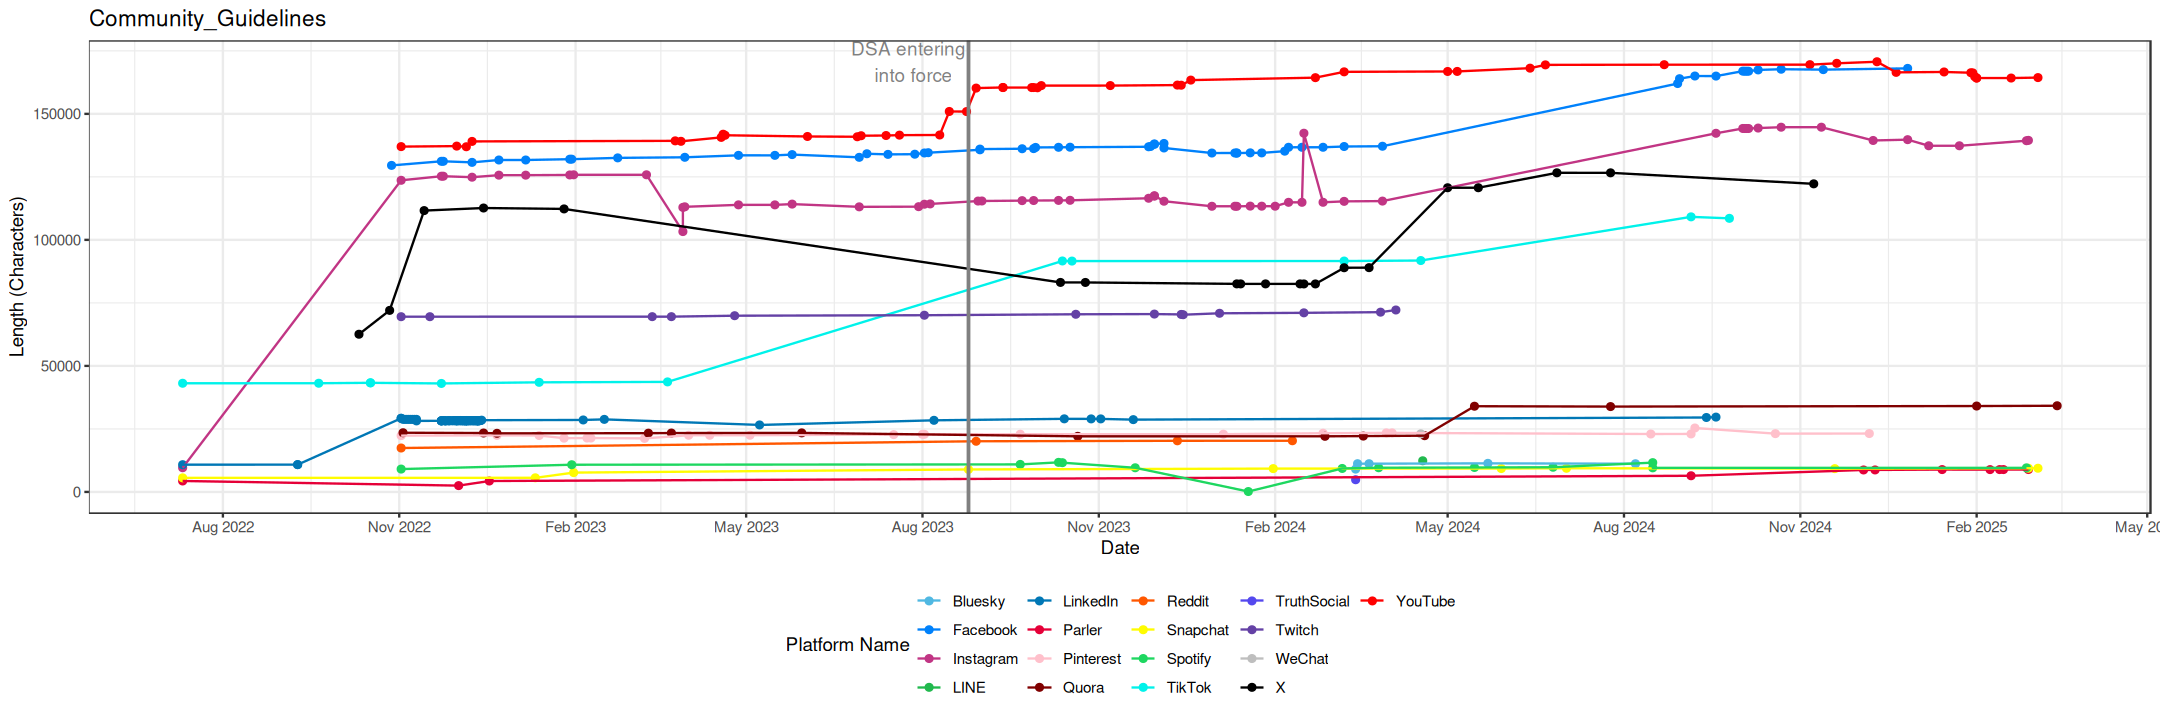

In [12]:
options(repr.plot.width=18, repr.plot.height=6)
colors <- c("Facebook"="#0081FB", "Instagram"="#C13584", 
            "X"="#000000", "LINE"="#21B94E", "LinkedIn"="#0077B5",
            "Parler"="#e50038", "Spotify"="#1ed760", "WeChat"="gray",
            "Pinterest"="#FFC0CB", "Quora"="#800000", "Reddit"="#FF5700",
            "Snapchat"= "#FFFC00", "YouTube"="#FF0000", "Bluesky"="#50B8E2",
            "TruthSocial"="#5448EE", "Twitch"="#6441a5","TikTok"="#00f2ea")

plot_length <- function(df, policy_type) {

    d = df[df$policy == policy_type,]
    y_max <- max(d$chars)

    ggplot(d,
       aes(x = date, y = chars, color = platform)) +
       geom_point() +
       geom_line() +
       theme_bw() +
       scale_color_manual(values = colors) +
       xlab("Date") +
       ylab("Length (Characters)") +
       labs(title = policy_type, color = "Platform Name") +
       geom_vline(xintercept=as.Date("2023-08-25"),
                  color='#808080',
                  linewidth=0.8) +
       annotate("text",x=(as.Date("2023-08-25") - 30),
                y=y_max,
                label="DSA entering \n into force",
                color="#808080") +
      #geom_vline(xintercept=as.Date("2022-10-28"),color='#808080',size=0.8) +
      #annotate("text",x=as.Date("2022-09-01"), y=-100, label="Twitter/X",color="#808080") +
       scale_x_date(date_breaks = "3 months", date_labels = "%b %Y") +
       theme(legend.position = "bottom")
}

plot_length(df, 'Community_Guidelines')

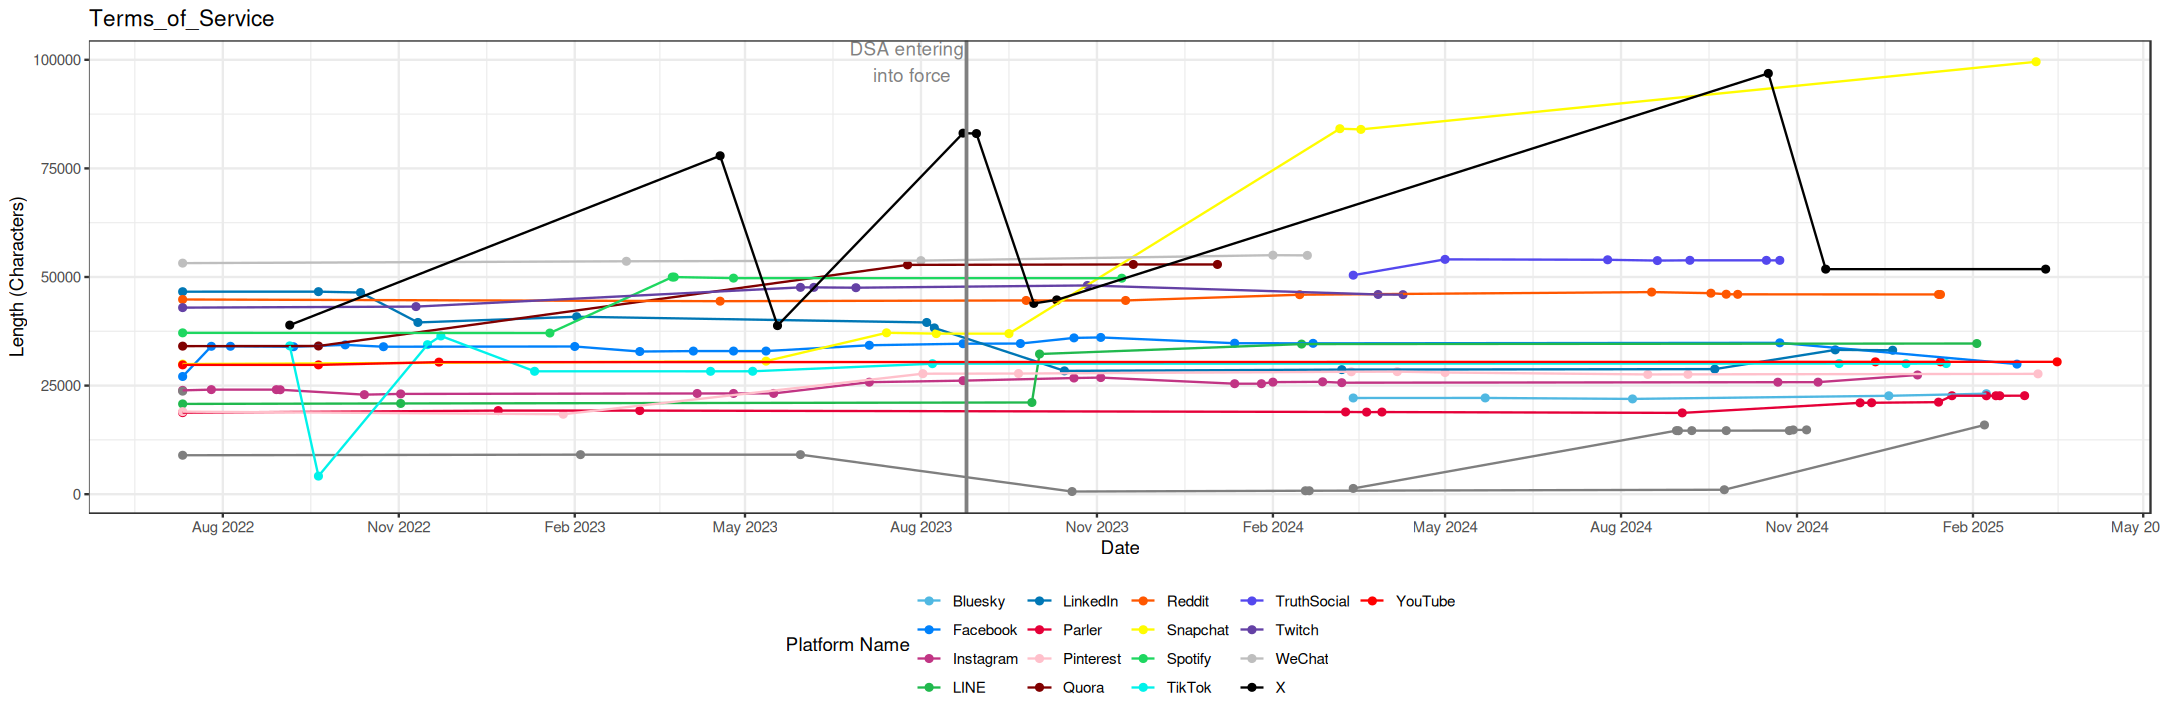

In [13]:
plot_length(df, 'Terms_of_Service')

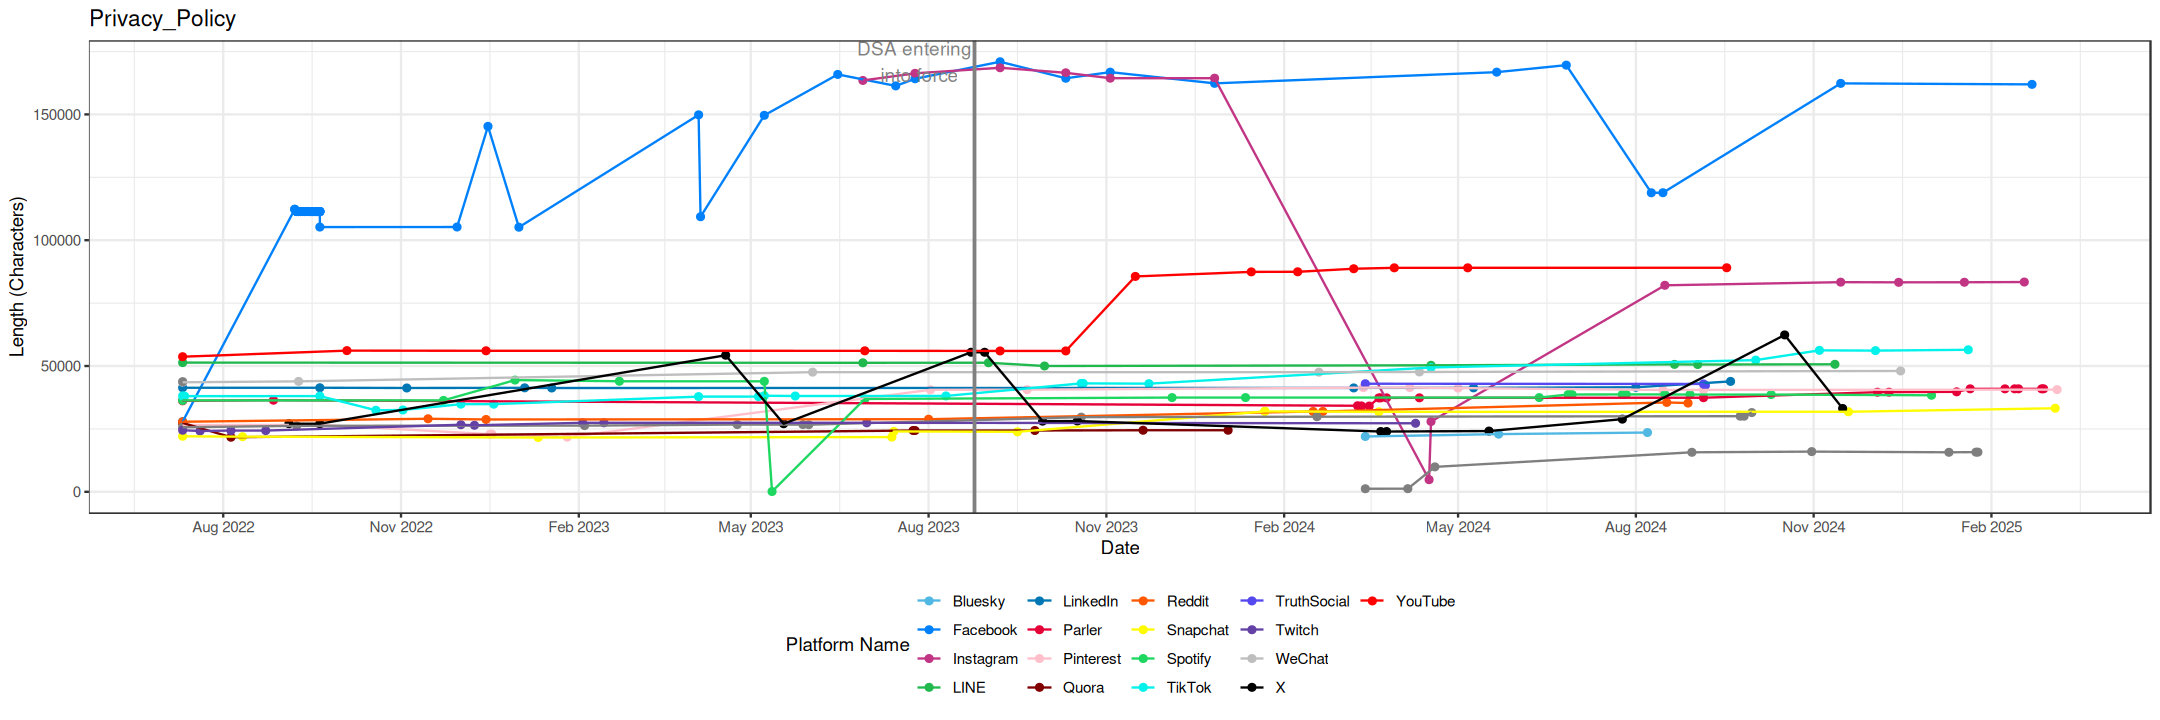

In [14]:
plot_length(df, 'Privacy_Policy')